In [8]:
import os
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from metient.util import plotting_util as putil
import sys
sys.path.append(os.path.join(os.getcwd(), "metient/jupyter_notebooks/calibrate_analysis"))
import utilities as ut


four_dataset_colors = {"Melanoma":"#b84988","HGSOC":"#06879e","HR-NB":"#5a9e09", "NSCLC":"#d4892a"}

REPO_DIR = '/lila/data/morrisq/divyak/projects/metient/metient/data'
OUTPUT_DIR = os.path.join(REPO_DIR, '../jupyter_notebooks', 'output_plots')
DATASET_NAMES = [ "HGSOC", "Melanoma", "HR-NB", "NSCLC"]
CALIBRATE_DIRS = [os.path.join(REPO_DIR,"mcpherson_ovarian_2016/metient_outputs/hgsoc_bs2048_runs16_solvepolys_12112024/calibrate"),
                  os.path.join(REPO_DIR,"sanborn_melanoma_2015/metient_outputs/melanoma_bs2048_runs16_solvepolys_12112024/calibrate"),
                  os.path.join(REPO_DIR,"gundem_neuroblastoma_2023/metient_outputs/hrnb_bs4096_runs16_solvepolys_12112024/calibrate"),
                  os.path.join(REPO_DIR,"tracerx_nsclc/metient_outputs/tracerx_trees_bs4096_runs8_12112024/calibrate",)]

desired_order = ["single-source", 'multi-source', "reseeding", "primary single-source"]

### Load all calibrate inferred trees

What are different metrics (e.g. seeding pattern, clonality, phyleticity) for the top tree, as determined by calibrate? or by a seeding site penalizing model? or migration number penalizing model?

In [6]:
trees_df = ut.build_top_calibrate_tree_df(CALIBRATE_DIRS, DATASET_NAMES)
trees_df

HGSOC 13
Melanoma 7
HR-NB 30
NSCLC 128
Not LUAD or LUSC subtype CRUK0702
Not LUAD or LUSC subtype CRUK0514
Not LUAD or LUSC subtype CRUK0325
Not LUAD or LUSC subtype CRUK0718
Not LUAD or LUSC subtype CRUK0422
Not LUAD or LUSC subtype CRUK0596
Not LUAD or LUSC subtype CRUK0476
Not LUAD or LUSC subtype CRUK0719
Not LUAD or LUSC subtype CRUK0100
Not LUAD or LUSC subtype CRUK0557
Not LUAD or LUSC subtype CRUK0099
Not LUAD or LUSC subtype CRUK0587
Not LUAD or LUSC subtype CRUK0524
Not LUAD or LUSC subtype CRUK0484
Not LUAD or LUSC subtype CRUK0769
Not LUAD or LUSC subtype CRUK0097
Not LUAD or LUSC subtype CRUK0698
Not LUAD or LUSC subtype CRUK0640
Not LUAD or LUSC subtype CRUK0013
Not LUAD or LUSC subtype CRUK0598
Not LUAD or LUSC subtype CRUK0245


,Dataset,Patient id,Filename,Lowest cal loss,Subtype,Num sites,Num trees on Pareto,Multiple trees w/ same pars metrics,Multiple trees w/ diff pars metrics,Root clone observed site,Top cal seeding pattern,Top cal site clonality,Top cal genetic clonality,Top cal phyleticity,Top cal tracerx phyleticity,Top cal % migs poly,Top cal num ss,Top cal seeding clusters,Top cal % metastatic sites,Lowest mig seeding pattern,Lowest mig % migs poly,Lowest mig num ss,Lowest comig seeding pattern,Lowest comig % migs poly,Lowest comig num ss,Lowest ss seeding pattern,Lowest ss % migs poly,Lowest ss num ss,Lowest ss seeding clusters,Pars metrics
0,HGSOC,1,/lila/data/morrisq/divyak/projects/metient/met...,327.730,N/A,7,1,False,False,Distant,primary single-source,polyclonal,polyclonal,monophyletic,polyphyletic,33.333,1,"[0, 1, 4, 6, 7]",0.000,primary single-source,33.333,1,primary single-source,33.333,1,primary single-source,33.333,1,"[0, 1, 4, 6, 7]","[(9, 6, 1)]"
1,HGSOC,10,/lila/data/morrisq/divyak/projects/metient/met...,177.363,N/A,3,1,False,False,Distant,primary single-source,polyclonal,polyclonal,monophyletic,polyphyletic,100.000,1,"[0, 1, 4, 5]",0.000,primary single-source,100.000,1,primary single-source,100.000,1,primary single-source,100.000,1,"[0, 1, 4, 5]","[(5, 2, 1)]"
2,HGSOC,2,/lila/data/morrisq/divyak/projects/metient/met...,50.951,N/A,2,1,False,False,None,primary single-source,monoclonal,monoclonal,monophyletic,monophyletic,0.000,1,[1],0.000,primary single-source,0.000,1,primary single-source,0.000,1,primary single-source,0.000,1,[1],"[(1, 1, 1)]"
3,HGSOC,3,/lila/data/morrisq/divyak/projects/metient/met...,480.657,N/A,8,1,False,False,Distant,primary single-source,polyclonal,polyclonal,monophyletic,polyphyletic,71.429,1,"[0, 1, 2, 3, 5, 6]",0.000,primary single-source,71.429,1,primary single-source,71.429,1,primary single-source,71.429,1,"[0, 1, 2, 3, 5, 6]","[(14, 7, 1)]"
4,HGSOC,4,/lila/data/morrisq/divyak/projects/metient/met...,127.852,N/A,4,1,False,False,None,primary single-source,monoclonal,monoclonal,monophyletic,monophyletic,0.000,1,[1],0.000,primary single-source,0.000,1,primary single-source,0.000,1,primary single-source,0.000,1,[1],"[(3, 3, 1)]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,NSCLC,CRUK0794,/lila/data/morrisq/divyak/projects/metient/met...,51.186,LUAD,2,1,False,False,None,primary single-source,monoclonal,monoclonal,monophyletic,monophyletic,0.000,1,[4],0.000,primary single-source,0.000,1,primary single-source,0.000,1,primary single-source,0.000,1,[4],"[(1, 1, 1)]"
163,NSCLC,CRUK0799,/lila/data/morrisq/divyak/projects/metient/met...,92.951,LUAD,3,1,False,False,None,primary single-source,monoclonal,polyclonal,polyphyletic,polyphyletic,0.000,1,"[0, 13]",0.000,primary single-source,0.000,1,primary single-source,0.000,1,primary single-source,0.000,1,"[0, 13]","[(2, 2, 1)]"
164,NSCLC,CRUK0810,/lila/data/morrisq/divyak/projects/metient/met...,226.780,LUAD,6,3,False,True,None,single-source,monoclonal,polyclonal,monophyletic,polyphyletic,0.000,2,"[1, 26, 19, 17]",20.000,single-source,0.000,2,single-source,0.000,2,primary single-source,20.000,1,"[1, 17, 19, 25, 26]","[(5, 5, 2), (5, 5, 2), (6, 5, 1)]"
165,NSCLC,CRUK0817,/lila/data/morrisq/divyak/projects/metient/met...,50.685,LUAD,2,1,False,False,None,primary single-source,monoclonal,monoclonal,monophyletic,monophyletic,0.000,1,[1],0.000,primary single-source,0.000,1,primary single-source,0.000,1,primary single-source,0.000,1,[1],"[(1, 1, 1)]"


In [ ]:

# pids = ['H118706', 'CRUK0620', 'CRUK0559', 'CRUK0290']

Patients with 3 or more unique pars metrics ['H103207', 'CRUK0487', 'CRUK0559']
[(7, 5, 3), (9, 5, 2), (11, 5, 1)]
[(8, 4, 3), (8, 5, 2), (9, 4, 2), (10, 4, 1)]
[(7, 5, 3), (9, 5, 2), (10, 5, 1)]
[['Migration #', 'Comigration #', 'Seeding sites'], ('H103207', [[11, 10, 3], [9, 10, 6], [7, 10, 9]]), ('CRUK0487', [[10, 8, 3], [9, 8, 6], [8, 10, 6], [8, 8, 9]]), ('CRUK0559', [[10, 10, 3], [9, 10, 6], [7, 10, 9]])]


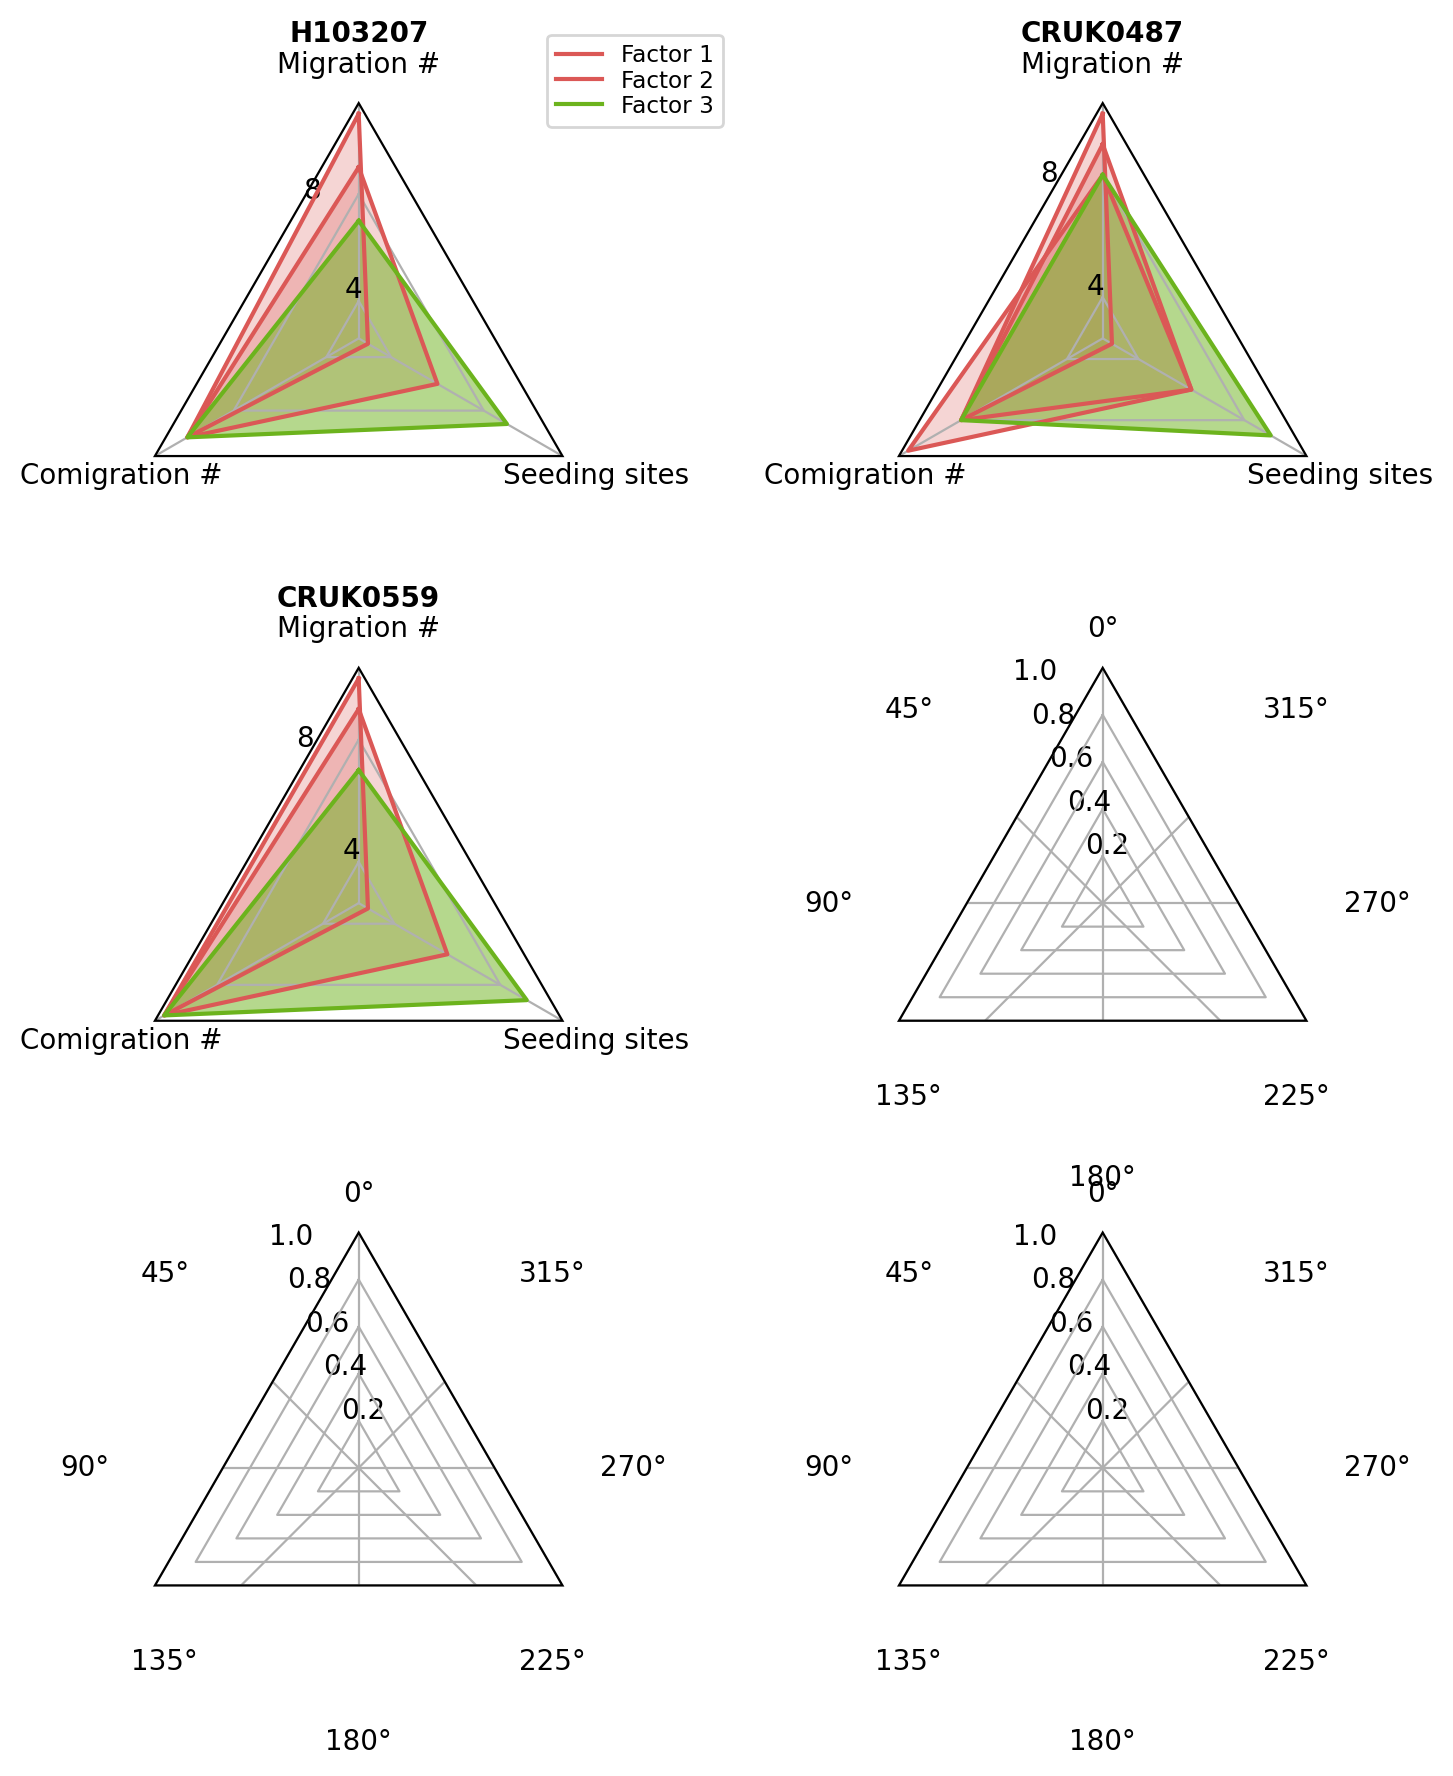

In [11]:

pids = []
for i, row in trees_df.iterrows():
    if len(set(row['Pars metrics'])) >= 3:
        #print(row['Patient id'], len(set(row['Pars metrics'])))
        pids.append(row['Patient id'])
print("Patients with 3 or more unique pars metrics", pids)
N = 3
theta = ut.radar_factory(N, frame='polygon')

data = ut.get_patient_pars_metrics(trees_df, pids)
print(data)
spoke_labels = data.pop(0)

fig, axs = plt.subplots(figsize=(8, 10), nrows=3, ncols=2,
                        subplot_kw=dict(projection='radar'),dpi=200)
fig.subplots_adjust(wspace=0.5, hspace=0.20, top=0.85, bottom=0.05)


# Plot the four cases from the example data on separate Axes
for ax, (title, case_data) in zip(axs.flat, data):
    ax.set_rgrids([4,8,12,16])
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                 horizontalalignment='center', verticalalignment='center')
    colors = ["#db5856" for _ in range(len(case_data)-1)]+["#6cb31d"]
    alphas = [0.25 for _ in range(len(case_data)-1)]+[0.5]
    for d, color, alpha in zip(case_data, colors, alphas):
        ax.plot(theta, d, color=color)
        ax.fill(theta, d, facecolor=color, alpha=alpha, label='_nolegend_')
    ax.set_varlabels(spoke_labels, )

# add legend relative to top-left plot
labels = ('Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5')
legend = axs[0, 0].legend(labels, loc=(0.9, .95),
                          labelspacing=0.1, fontsize='small')

plt.savefig(os.path.join(OUTPUT_DIR, f"pareto_treadeoff_examples.png"), dpi=300,  bbox_inches='tight', pad_inches=0.2)

plt.show()

In [12]:
# How many total sites do we have across all patients
print("Unique anatomical sites", sum(trees_df.groupby('Patient id')['Num sites'].mean()))

# how many unique patients
print("Unique patients", len(trees_df['Patient id'].unique()))


Unique anatomical sites 479.0
Unique patients 167


### How many patients have the root clone detected in a met?

Unique patients with a root clone observed in met: 30
1 5 0
0 4 0
0 5 0
10 4 1
    Dataset  Root clone in LN  Root clone in distant  Root clone in both
0  Melanoma            14.286                 71.429               0.000
1     HGSOC             0.000                 57.143               0.000
2     HR-NB             0.000                 18.519               0.000
3     NSCLC             7.937                  3.175               0.794


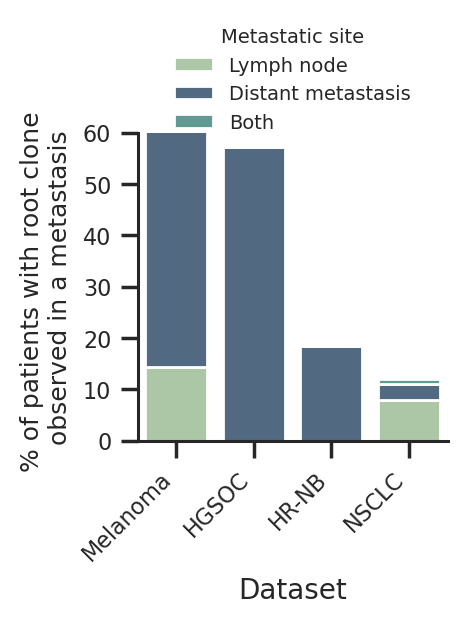

In [13]:

def adjust_lightness(hex_color, amount=0.5):
    import colorsys
    import matplotlib.colors as mc
    h = hex_color.strip("#")
    c = tuple(float(int(h[i:i+2], 16)/256) for i in (0, 2, 4))
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

print("Unique patients with a root clone observed in met:", len(trees_df[trees_df['Root clone observed site']!='None']['Patient id'].unique()))

root_clone_in_ln_met_df = trees_df[(trees_df['Root clone observed site']=='Lymph node')]
root_clone_in_other_met_df = trees_df[(trees_df['Root clone observed site']=='Distant')]
root_clone_in_both_df = trees_df[(trees_df['Root clone observed site']=='Both')]

data = []
for dataset in four_dataset_colors.keys():
    num_tot_pts = len(trees_df[trees_df['Dataset']==dataset]['Patient id'].unique())
    num_root_clone_in_ln_met_pts = len(root_clone_in_ln_met_df[(root_clone_in_ln_met_df['Dataset']==dataset)]['Patient id'].unique())
    num_root_clone_in_other_met_pts = len(root_clone_in_other_met_df[(root_clone_in_other_met_df['Dataset']==dataset)]['Patient id'].unique())
    num_root_clone_both_met_pts = len(root_clone_in_both_df[(root_clone_in_both_df['Dataset']==dataset)]['Patient id'].unique())

    print(num_root_clone_in_ln_met_pts,num_root_clone_in_other_met_pts, num_root_clone_both_met_pts )
    data.append([dataset, 100*(num_root_clone_in_ln_met_pts/num_tot_pts), 100*(num_root_clone_in_other_met_pts/num_tot_pts), 100*(num_root_clone_both_met_pts/num_tot_pts)])

root_clone_df = pd.DataFrame(data, columns=['Dataset', 'Root clone in LN', 'Root clone in distant', 'Root clone in both'])
print(root_clone_df)
sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.1})
plt.figure(figsize=(2, 2), dpi=200)
ln_colors = ['#A8CD9F']
distant_colors = ['#496989']
both_colors = ['#58A399']
sns.barplot(x='Dataset', y='Root clone in LN', data=root_clone_df, palette=ln_colors, order=four_dataset_colors.keys(), label="Lymph node")
sns.barplot(x='Dataset', y='Root clone in distant', data=root_clone_df, palette=distant_colors, order=four_dataset_colors.keys(), label="Distant metastasis", bottom=root_clone_df['Root clone in LN'])
snsfig=sns.barplot(x='Dataset', y='Root clone in both', data=root_clone_df, palette=both_colors, order=four_dataset_colors.keys(), label="Both", bottom=root_clone_df['Root clone in distant']+root_clone_df['Root clone in LN'])
# snsfig = sns.barplot(x=DATASET_NAMES[1:], y=ys, palette=four_dataset_colors.values(), order=four_dataset_colors.keys())
plt.ylabel("% of patients with root clone \nobserved in a metastasis", fontsize=9)
plt.xlabel("Dataset")
handles, labels = snsfig.get_legend_handles_labels()  # Get existing handles and labels

legend = snsfig.legend(handles=handles, labels=labels, loc='upper center',  bbox_to_anchor=(0.5, 1.4), ncol=1, 
           frameon=False, fontsize=7)
legend.set_title("Metastatic site", prop={'size': 7})  # Change '10' to your desired fontsize

plt.ylim(0,60)
snsfig.set_xticklabels(snsfig.get_xticklabels(), rotation=45, horizontalalignment='right')
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR, f"percent_pts_root_clone_in_met.png"), dpi=300,  bbox_inches='tight', pad_inches=0.2)


### How many trees are on the Pareto front?

Average number of pareto front trees with 1 met: 1.0
Average number of pareto front trees with > 1 met: 1.7763157894736843
Average number of pareto front trees: 1.3532934131736527
Max number of pareto front trees: 11
Percent of patients with multiple trees: 17.365269461077844 29
Percent of patients with multiple trees and > 1 met: 38.1578947368421 29 / 76
Percent of patients with multiple trees and > 2 met: 52.94117647058823 18 / 34
Percent of patients with multiple trees w/ same parsimony metric: 0.0 0
Percent of patients with multiple trees w/ different parsimony metric: 17.365269461077844 29


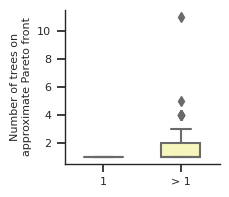

In [14]:
one_met_df = trees_df[trees_df['Num sites'] == 2]
multi_met_df = trees_df[trees_df['Num sites'] > 2]
three_met_df = trees_df[trees_df['Num sites'] > 3]

print("Average number of pareto front trees with 1 met:", one_met_df['Num trees on Pareto'].mean())
print("Average number of pareto front trees with > 1 met:", multi_met_df['Num trees on Pareto'].mean())
print("Average number of pareto front trees:", trees_df['Num trees on Pareto'].mean())
print("Max number of pareto front trees:", trees_df['Num trees on Pareto'].max())

# Number of patients with multiple trees
percent_patients = 100*len(trees_df[(trees_df['Multiple trees w/ same pars metrics']==1)|(trees_df['Multiple trees w/ diff pars metrics']==1)])/len(trees_df)
print("Percent of patients with multiple trees:", percent_patients, len(trees_df[(trees_df['Multiple trees w/ same pars metrics']==1)|(trees_df['Multiple trees w/ diff pars metrics']==1)]))

# Number of patients with multiple trees and > 1 met
percent_patients = 100*len(multi_met_df[(multi_met_df['Multiple trees w/ same pars metrics']==1)|(multi_met_df['Multiple trees w/ diff pars metrics']==1)])/len(multi_met_df)
print("Percent of patients with multiple trees and > 1 met:", percent_patients, len(multi_met_df[(multi_met_df['Multiple trees w/ same pars metrics']==1)|(multi_met_df['Multiple trees w/ diff pars metrics']==1)]),"/", len(multi_met_df))

# Number of patients with multiple trees and > 2 met
percent_patients = 100*len(three_met_df[(three_met_df['Multiple trees w/ same pars metrics']==1)|(three_met_df['Multiple trees w/ diff pars metrics']==1)])/len(three_met_df)
print("Percent of patients with multiple trees and > 2 met:", percent_patients, len(three_met_df[(three_met_df['Multiple trees w/ same pars metrics']==1)|(three_met_df['Multiple trees w/ diff pars metrics']==1)]),"/", len(three_met_df))


# How many patients have a pareto front with multiple trees with the same parsimony metric
percent_patients = 100*len(trees_df[trees_df['Multiple trees w/ same pars metrics']==1])/len(trees_df)
print("Percent of patients with multiple trees w/ same parsimony metric:", percent_patients, len(trees_df[trees_df['Multiple trees w/ same pars metrics']==1]))

# How many patients have a pareto front with multiple trees with different parsimony metrics
percent_patients = 100*len(trees_df[trees_df['Multiple trees w/ diff pars metrics']==1])/len(trees_df)
print("Percent of patients with multiple trees w/ different parsimony metric:", percent_patients, len(trees_df[trees_df['Multiple trees w/ diff pars metrics']==1]))

sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
plt.figure(figsize=(2, 2), dpi=100)
snsfig = sns.boxplot(data=[one_met_df['Num trees on Pareto'], multi_met_df['Num trees on Pareto']], 
            width=0.5, palette="Set3")
plt.ylabel("Number of trees on\napproximate Pareto front", fontsize=8)
plt.xticks([0, 1], ['1', '> 1'])
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)

### What is the average genetic distance on migrating vs. non-migrations for patients with only one history on the pareto front

In [15]:
single_pareto_soln = trees_df[trees_df['Num trees on Pareto']==1]
single_pareto_soln['Dataset'].value_counts()

NSCLC       106
HR-NB        19
HGSOC         7
Melanoma      6
Name: Dataset, dtype: int64

138
T-statistic: 5.614139841717207, p = 4.137296061397786e-08


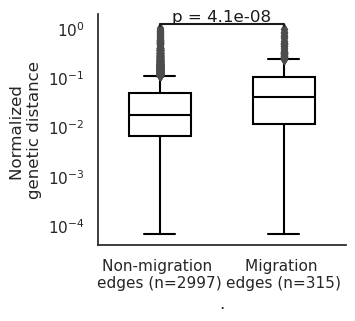

(0.0450174377761088, 0.09015753817391611)

In [22]:
from scipy import stats
import gzip
import pickle
from metient.util.globals import *
import numpy as np

def gen_dist_boxplot(migrating, nonmigrating):
    df = pd.DataFrame({
        'Normalized \ngenetic distance': np.concatenate([nonmigrating, migrating]),
        '.': [f'Non-migration \nedges (n={len(nonmigrating)})']*len(nonmigrating)+[f'Migration \nedges (n={len(migrating)})']*len(migrating)
    })

    t_stat, p_value = stats.ttest_ind(migrating, nonmigrating,equal_var=False)
    print(f"T-statistic: {t_stat}, p = {p_value}")

    sns.set(style="white")

    plt.figure(figsize=(3.2, 3))
    ax = sns.boxplot(x='.', y='Normalized \ngenetic distance', data=df,width=0.5, showfliers=True,
                    boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.5),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    medianprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5))
#     ax = sns.violinplot(x='.', y='Normalized \ngenetic distance', data=df,)

    x1, x2 = 0, 1  # locations for the groups to annotate
    y, h, col = df['Normalized \ngenetic distance'].max() + 0.1, 0.1, 'k'

    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h, f"p = {p_value:.1e}", ha='center', va='bottom', color=col)
    sns.despine()
    plt.yscale('log')
    #plt.ylim(-0.05,1.0)
    plt.savefig(os.path.join(OUTPUT_DIR, f"migrating_vs_nonmigrating_edges.png"), dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.show()
    plt.close()
    
single_pareto_soln = trees_df[trees_df['Num trees on Pareto']==1]
print(len(single_pareto_soln))

non_migrating_edges, migrating_edges = [],[]
for fn in single_pareto_soln['Filename']:
    with gzip.open(fn, 'rb') as f:
        pkl = pickle.load(f)
        gen_dist = torch.tensor(pkl[OUT_GEN_DIST_KEY][0])
        V = torch.tensor(pkl[OUT_LABElING_KEY][0])
        indices, values, size = pkl[OUT_ADJ_KEY][0]
        A = torch.sparse_coo_tensor(indices.cpu(), values.cpu(), tuple(size)).to_dense()
        X = V.T @ V # 1 if two nodes are the same color
        # Calculate if 2 nodes are in diff sites and there's an edge between them (i.e there is a migration edge)
        R = torch.mul(A, (1-X))
        #print(torch.nonzero(R))
        # Calculate if 2 nodes are in same site and there's an edge between them (i.e there is no migration edge)
        Y = torch.mul(A, X)
        #print(torch.nonzero(Y))
        migrating_edges_gen_dist = torch.mul(R, gen_dist)
        migrating_edges_gen_dist = migrating_edges_gen_dist[migrating_edges_gen_dist!=0].tolist()
        nonmigrating_edges_gen_dist = torch.mul(Y, gen_dist)
        nonmigrating_edges_gen_dist = nonmigrating_edges_gen_dist[nonmigrating_edges_gen_dist!=0].tolist()

        non_migrating_edges.extend(nonmigrating_edges_gen_dist)
        migrating_edges.extend(migrating_edges_gen_dist)
gen_dist_boxplot(migrating_edges, non_migrating_edges)
avg_migrating_edges_gen_dist = sum(migrating_edges)/len(migrating_edges)
avg_nonmigrating_edges_gen_dist = sum(non_migrating_edges)/len(non_migrating_edges)
avg_nonmigrating_edges_gen_dist,avg_migrating_edges_gen_dist 

### How different are the colonizing clones from Metient vs. seeding site penalizing model?

In [23]:
num_same_clones = 0
num_diff_clones = 0
num_pts_diff_clones = 0
for i,row in trees_df.iterrows():
    top_cal_clusters = set(row['Top cal seeding clusters'])
    lowest_ss_clusters = set(row['Lowest ss seeding clusters'])
    num_same_clones += len(top_cal_clusters.intersection(lowest_ss_clusters))
    num_diff_clones += len(top_cal_clusters.symmetric_difference(lowest_ss_clusters))
    if len(top_cal_clusters.symmetric_difference(lowest_ss_clusters)) != 0:
        num_pts_diff_clones += 1

print("same clones", num_same_clones, "diff clones", num_diff_clones, "num_pts_diff_clones", num_pts_diff_clones)

same clones 400 diff clones 40 num_pts_diff_clones 16


### Visualize top calibrated seeding patterns together in a stacked bar plot

Index(['multi-source', 'primary single-source', 'single-source', 'reseeding'], dtype='object', name='Top cal seeding pattern') Top cal seeding pattern  multi-source  primary single-source  single-source  \
Dataset                                                                       
   NSCLC                        0.794                 86.508         12.698   
  HR-NB                         3.704                 77.778         18.519   
 HGSOC                          0.000                100.000          0.000   
Melanoma                        0.000                 85.714         14.286   

Top cal seeding pattern  reseeding  
Dataset                             
   NSCLC                     0.000  
  HR-NB                      0.000  
 HGSOC                       0.000  
Melanoma                     0.000  


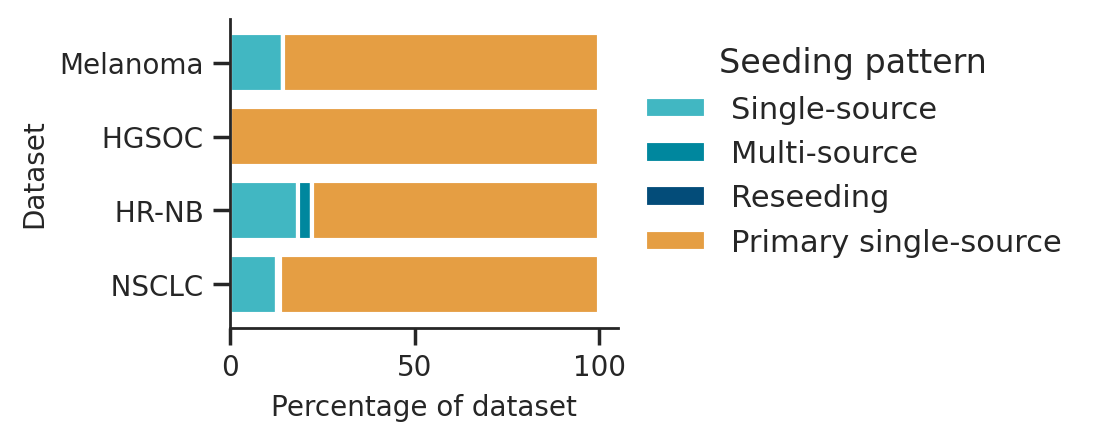

Index(['multi-source', 'primary single-source', 'reseeding', 'single-source'], dtype='object', name='Lowest mig seeding pattern') Lowest mig seeding pattern  multi-source  primary single-source  reseeding  \
Dataset                                                                      
   NSCLC                           3.175                 84.127      0.000   
  HR-NB                            7.407                 70.370      3.704   
 HGSOC                             0.000                100.000      0.000   
Melanoma                           0.000                 85.714      0.000   

Lowest mig seeding pattern  single-source  
Dataset                                    
   NSCLC                           12.698  
  HR-NB                            18.519  
 HGSOC                              0.000  
Melanoma                           14.286  


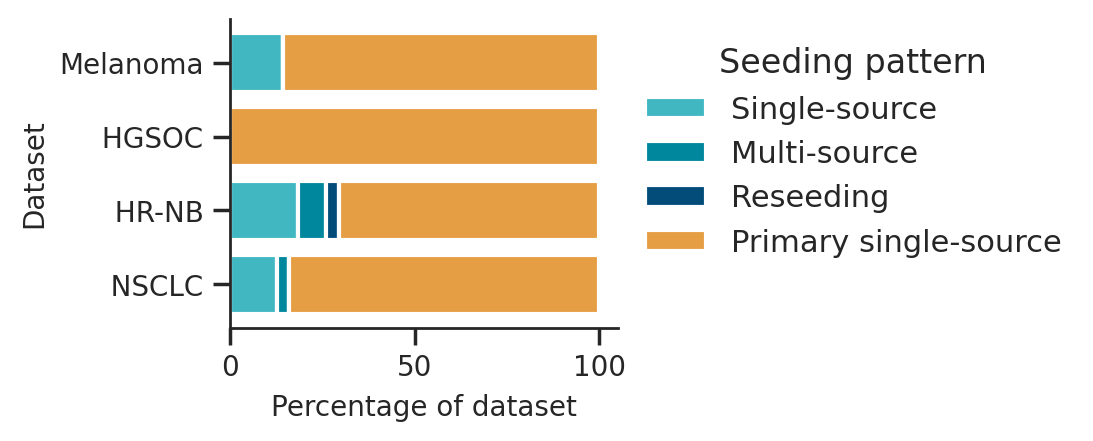

Index(['primary single-source', 'single-source', 'multi-source', 'reseeding'], dtype='object', name='Lowest comig seeding pattern') Lowest comig seeding pattern  primary single-source  single-source  \
Dataset                                                              
   NSCLC                                     87.302         12.698   
  HR-NB                                      81.481         18.519   
 HGSOC                                      100.000          0.000   
Melanoma                                     85.714         14.286   

Lowest comig seeding pattern  multi-source  reseeding  
Dataset                                                
   NSCLC                             0.000      0.000  
  HR-NB                              0.000      0.000  
 HGSOC                               0.000      0.000  
Melanoma                             0.000      0.000  


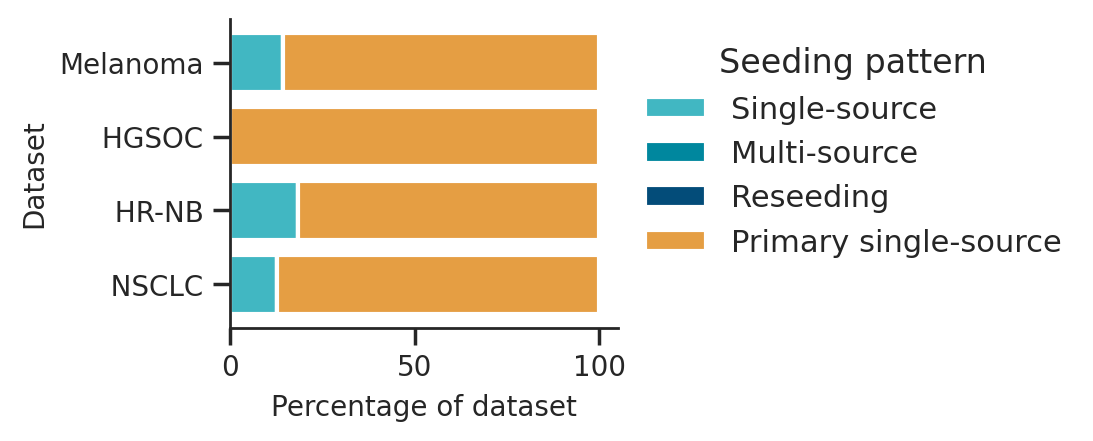

Index(['primary single-source', 'single-source', 'multi-source', 'reseeding'], dtype='object', name='Lowest ss seeding pattern') Lowest ss seeding pattern  primary single-source  single-source  multi-source  \
Dataset                                                                         
   NSCLC                                 100.000          0.000         0.000   
  HR-NB                                  100.000          0.000         0.000   
 HGSOC                                   100.000          0.000         0.000   
Melanoma                                 100.000          0.000         0.000   

Lowest ss seeding pattern  reseeding  
Dataset                               
   NSCLC                       0.000  
  HR-NB                        0.000  
 HGSOC                         0.000  
Melanoma                       0.000  


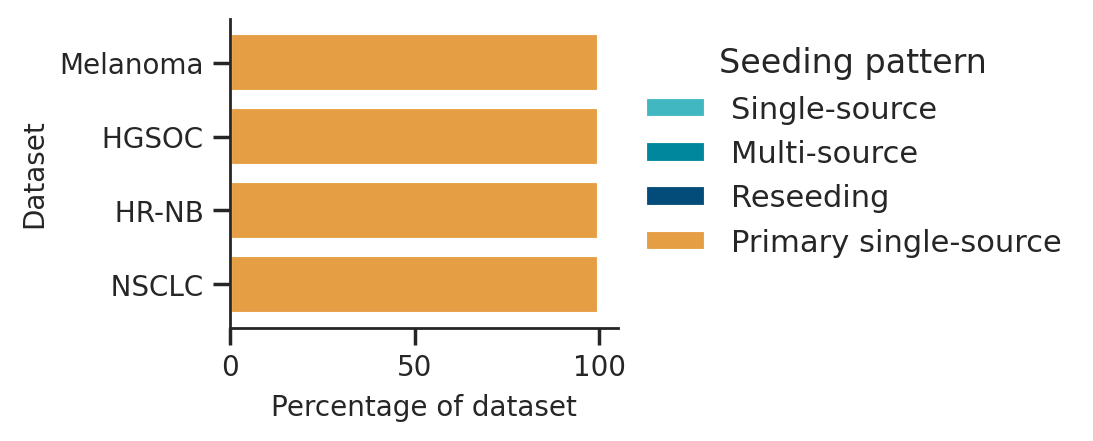

In [24]:
import numpy as np

def stacked_bar_seeding_pattern(df, key, output_name):
    df = df.copy(deep=True)
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10, 'axes.linewidth': 1.0})

    # hack to get desired order...
    dataset_map = {'Melanoma':'Melanoma', 'HGSOC':' HGSOC', 'HR-NB':'  HR-NB', 'NSCLC':'   NSCLC'}
    df['Dataset'] = df.apply(lambda row: dataset_map[row['Dataset']], axis=1)

    # Calculate the count of each category within each dataset
    category_counts = df.groupby(['Dataset', key]).size().unstack(fill_value=0)

    # Calculate proportions
    category_proportions = category_counts.div(category_counts.sum(axis=1), axis=0)*100
    for ptrn in desired_order:
        if ptrn not in category_proportions.columns: # the seeding pattern never shows up
            category_proportions[ptrn] = 0.0
    print(category_proportions.columns, category_proportions)
    fig, ax = plt.subplots(figsize=(2.5,2), dpi=200)

    # Variables to store the bottom for each bar
    bottoms = np.zeros(len(category_proportions))

    # Colors for each category
    tab_colors = ["#41b7c2", "#00879e", "#034c79", "#e59e43",]
    colors = {d:c for d,c in zip(desired_order, tab_colors)}
    sns.set(style='ticks', font="Arial")
    # Plot each category
    for column_name in desired_order:
        column_data = category_proportions[column_name]
        ax.barh(category_proportions.index, column_data,left=bottoms, label=column_name, 
               color=colors[column_name], edgecolor='white', linewidth=1.5)
        bottoms += column_data.values


    ax.set_xlabel('Percentage of dataset')
    ax.set_ylabel('Dataset')
    legend = ax.legend(title='Seeding pattern', bbox_to_anchor=(1, 1), loc='upper left', frameon=False)  # Place legend outside the plot
    for text in legend.get_texts():
        text.set_text(text.get_text().capitalize())


    # Remove top and right axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_distribution.png"), dpi=300,  bbox_inches='tight', pad_inches=0.05)
    plt.show()

df = trees_df[trees_df['Dataset']!='Breast Cancer']
# df = df[df['Num sites']>2]
stacked_bar_seeding_pattern(df, 'Top cal seeding pattern', 'stacked_bar_top_cal_seeding_pattern')
stacked_bar_seeding_pattern(df, 'Lowest mig seeding pattern', 'stacked_bar_lowest_mig_seeding_pattern')
stacked_bar_seeding_pattern(df, 'Lowest comig seeding pattern', 'stacked_bar_lowest_comig_seeding_pattern')
stacked_bar_seeding_pattern(df, 'Lowest ss seeding pattern', 'stacked_bar_lowest_ss_seeding_pattern')


### Compare the distribution of the models

/scratch/lsftmp/10843700.tmpdir/ipykernel_29553/1631953201.py:11: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  proportion_df = model_df.groupby(['Model', 'Seeding pattern']).size().groupby(level=0).apply(lambda x: 100 * x / x.sum()).reset_index(name='Proportion')


Seeding pattern               Multi-source  Primary single-source  Reseeding  \
Model                                                                          
Metient-calibrate                    1.198                 85.629      0.000   
Migration \npenalizing model         3.593                 82.635      0.599   
Primary-only \nseeding model         0.000                100.000      0.000   

Seeding pattern               Single-source  
Model                                        
Metient-calibrate                    13.174  
Migration \npenalizing model         13.174  
Primary-only \nseeding model          0.000  


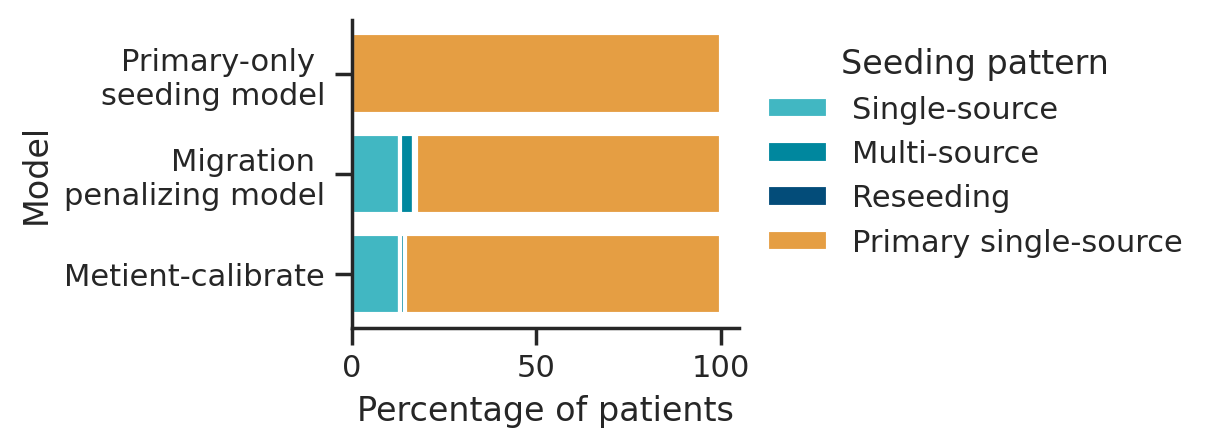

In [25]:
data = []
keys = ['Top cal seeding pattern', 'Lowest ss seeding pattern', 'Lowest mig seeding pattern',]
model_name_map = {"Top cal":"Metient-calibrate", "Lowest ss":"Primary-only \nseeding model", "Lowest mig":"Migration \npenalizing model"}

for i, row in trees_df.iterrows():
    for key in keys:
        pattern = 'Primary single-source' if row[key] == 'primary single-source' else 'Not primary single-source'
        pattern = row[key].capitalize()
        data.append([model_name_map[key.replace(" seeding pattern", "")],pattern])
model_df = pd.DataFrame(data, columns = ["Model", "Seeding pattern"])
proportion_df = model_df.groupby(['Model', 'Seeding pattern']).size().groupby(level=0).apply(lambda x: 100 * x / x.sum()).reset_index(name='Proportion')
category_proportions = proportion_df.pivot(index='Model', columns='Seeding pattern', values='Proportion').fillna(0)
print(category_proportions)

bottoms = np.zeros(len(category_proportions))
fig, ax = plt.subplots(figsize=(2.5,2),dpi=200)
#desired_order_general = ['Primary single-source', 'Not primary single-source']
desired_order_general = ['Single-source', 'Multi-source', 'Reseeding', 'Primary single-source']

#tab_colors = [ "#e59e43","#00879e", ]
tab_colors = ["#41b7c2", "#00879e", "#034c79", "#e59e43",]
colors = {d:c for d,c in zip(desired_order_general, tab_colors)}
sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 9, 'axes.linewidth': 1.0})
# Plot each category
for column_name in desired_order_general:
    column_data = category_proportions[column_name]
    ax.barh(category_proportions.index, column_data,left=bottoms, label=column_name, 
           color=colors[column_name], edgecolor='white', linewidth=1.5)
    bottoms += column_data.values

ax.set_xlabel('Percentage of patients')
ax.set_ylabel('Model')
legend = ax.legend(title='Seeding pattern', bbox_to_anchor=(1, 1), loc='upper left', frameon=False)  # Place legend outside the plot
for text in legend.get_texts():
    text.set_text(text.get_text().capitalize())

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_distribution.png"), dpi=300,  bbox_inches='tight', pad_inches=0.05)
plt.show()

Top cal % migs poly
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Melanoma v.s. HGSOC: Welch's t-test independent samples, P_val=3.599e-02 stat=2.361e+00
HGSOC v.s. HR-NB: Welch's t-test independent samples, P_val=4.848e-01 stat=-7.263e-01
HR-NB v.s. NSCLC: Welch's t-test independent samples, P_val=2.585e-02 stat=2.321e+00
Melanoma v.s. HR-NB: Welch's t-test independent samples, P_val=4.945e-02 stat=2.231e+00
HGSOC v.s. NSCLC: Welch's t-test independent samples, P_val=6.188e-01 stat=5.215e-01
Melanoma v.s. NSCLC: Welch's t-test independent samples, P_val=6.601e-03 stat=3.861e+00


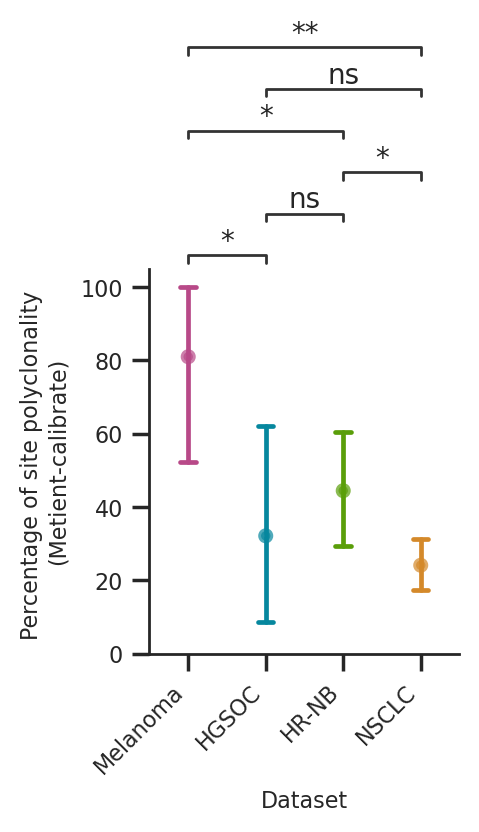

Top cal % metastatic sites
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Melanoma v.s. HGSOC: Welch's t-test independent samples, P_val=3.559e-01 stat=1.000e+00
HGSOC v.s. HR-NB: Welch's t-test independent samples, P_val=1.517e-02 stat=-2.600e+00
HR-NB v.s. NSCLC: Welch's t-test independent samples, P_val=3.121e-01 stat=1.026e+00
Melanoma v.s. HR-NB: Welch's t-test independent samples, P_val=5.394e-01 stat=-6.315e-01
HGSOC v.s. NSCLC: Welch's t-test independent samples, P_val=6.343e-05 stat=-4.140e+00
Melanoma v.s. NSCLC: Welch's t-test independent samples, P_val=9.834e-01 stat=-2.157e-02


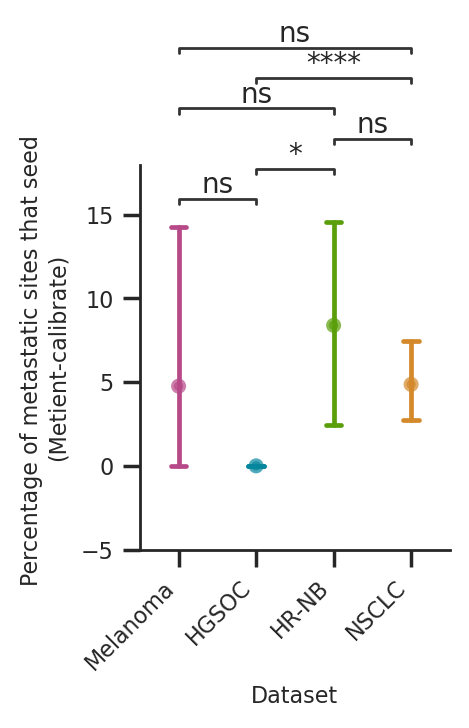

Top cal num ss
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Melanoma v.s. HGSOC: Welch's t-test independent samples, P_val=3.559e-01 stat=1.000e+00
HGSOC v.s. HR-NB: Welch's t-test independent samples, P_val=1.781e-02 stat=-2.530e+00


/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/statannot/statannot.py:109: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  stat, pval = stats.ttest_ind(


HR-NB v.s. NSCLC: Welch's t-test independent samples, P_val=2.438e-01 stat=1.188e+00
Melanoma v.s. HR-NB: Welch's t-test independent samples, P_val=4.191e-01 stat=-8.306e-01
HGSOC v.s. NSCLC: Welch's t-test independent samples, P_val=4.703e-05 stat=-4.217e+00
Melanoma v.s. NSCLC: Welch's t-test independent samples, P_val=9.586e-01 stat=-5.389e-02


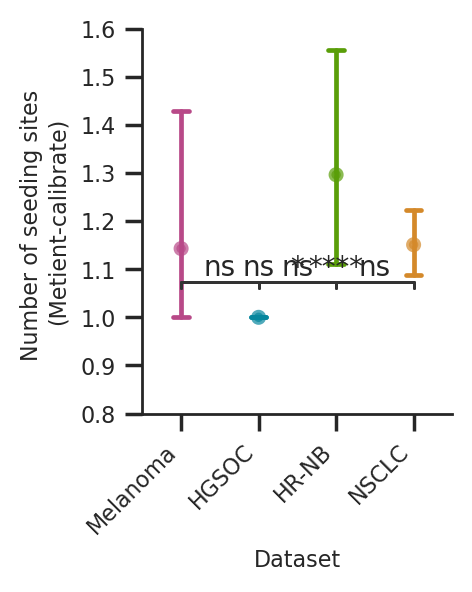

In [26]:
from statannot import add_stat_annotation
import itertools

def point_plot_comparing_datasets(df, key, ylim, ylabel, output_name, with_stat,offset=0.02):
    df = df.copy(deep=True)
    print(key)
    
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})

    fig = plt.figure(figsize=(2,2.5), dpi=200)
    order = ['Melanoma','HGSOC','HR-NB', 'NSCLC' ]
    #colors =  [sns.color_palette("Set1")[1],sns.color_palette("Set1")[2], sns.color_palette("Set1")[0],(0.5, 0.5, 0.5)]
    snsfig = sns.pointplot(data=df, x='Dataset', y=key, errwidth=1.7, order=order,
                           dodge=True, markers='.', errorbar='se', palette=four_dataset_colors.values(), capsize=0.2)
  
    if with_stat:
        
        add_stat_annotation(snsfig, data=df, x='Dataset', y=key,
                            box_pairs=itertools.combinations(order, 2),order=order, line_offset=offset,
                            test='t-test_welch', text_format='star', loc='outside', line_offset_to_box=0.1, 
                            text_offset=0.01, verbose=2,  fontsize=10, comparisons_correction=None,linewidth=1.0,
                            )
        
    snsfig.set_xticklabels(snsfig.get_xticklabels(), rotation=45, horizontalalignment='right')
    plt.xlabel("Dataset", fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.ylim(ylim[0],ylim[1])
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.7)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_distribution.png"), dpi=500,  bbox_inches='tight', pad_inches=0.1)

    plt.show()
    plt.close()
    
no_bc_df = trees_df[trees_df['Dataset']!='Breast Cancer']
point_plot_comparing_datasets(no_bc_df, 'Top cal % migs poly',(0,105), "Percentage of site polyclonality \n(Metient-calibrate)", 'num_migs_poly_calibrate_bw_datasets', True)
point_plot_comparing_datasets(no_bc_df, 'Top cal % metastatic sites',(-5,18), "Percentage of metastatic sites that seed \n(Metient-calibrate)", 'num_sites_metastasize_bw_datasets', True)
# point_plot_clonality(df, 'Lowest mig % migs poly', 'blah')
# point_plot_clonality(df, 'Lowest comig % migs poly', 'blah')
#point_plot_comparing_datasets(df, 'Lowest ss % migs poly', (0.3,1.1),"Fraction of migrations \nthat are polyclonal",'blah', True)
point_plot_comparing_datasets(no_bc_df, 'Top cal num ss', (0.8,1.6),"Number of seeding sites \n(Metient-calibrate)", 'num_ss_calibrate_bw_datasets', True, offset=0.1)



                      Type   Value
0    Lowest ss % migs poly  33.333
1    Lowest ss % migs poly 100.000
2    Lowest ss % migs poly   0.000
3    Lowest ss % migs poly  71.429
4    Lowest ss % migs poly   0.000
..                     ...     ...
329    Top cal % migs poly   0.000
330    Top cal % migs poly   0.000
331    Top cal % migs poly   0.000
332    Top cal % migs poly   0.000
333    Top cal % migs poly   0.000

[334 rows x 2 columns]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Lowest ss % migs poly v.s. Top cal % migs poly: t-test paired samples, P_val=2.560e-05 stat=4.331e+00


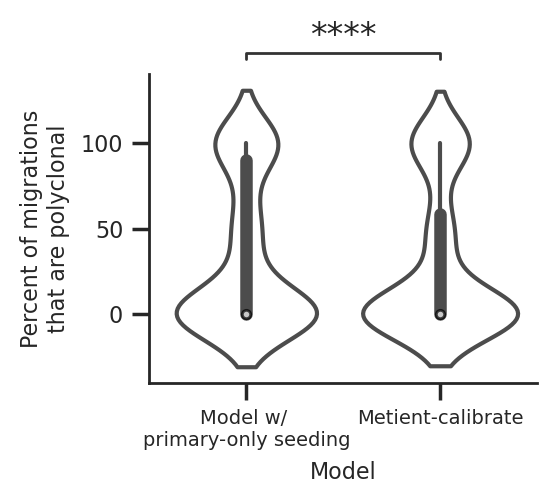

                 Type  Value
0    Lowest ss num ss      1
1    Lowest ss num ss      1
2    Lowest ss num ss      1
3    Lowest ss num ss      1
4    Lowest ss num ss      1
..                ...    ...
329    Top cal num ss      1
330    Top cal num ss      1
331    Top cal num ss      2
332    Top cal num ss      1
333    Top cal num ss      1

[334 rows x 2 columns]
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Lowest ss num ss v.s. Top cal num ss: t-test paired samples, P_val=1.517e-06 stat=-4.989e+00


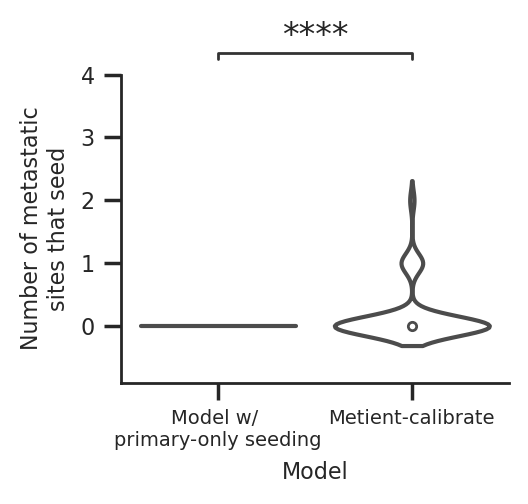

In [28]:
def violin_plot_comparison(df, keys,ylim, ylabel,output_name,subtract_one=False,):
    df = df.copy(deep=True)
    df_long = df.melt(value_vars=keys, var_name='Type', value_name='Value')
    print(df_long)
    if subtract_one: # for metastatic seeding sites vs all seeding sites
        df_long['Value'] = df_long['Value'] - 1
    sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 6, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2.5,2), dpi=200)
    
    types = df_long['Type'].unique()
    colors = ["#d44432", "#06879e"]
 
    snsfig = sns.violinplot(data=df_long, x='Type', y='Value', 
                           dodge=True, )
    for violin in plt.gca().collections:
        violin.set_facecolor('white')
        violin.set_edgecolor('black')  # Ensure black borders

    snsfig.set_xticklabels(['Model w/ \nprimary-only seeding', 'Metient-calibrate'], rotation=0, fontsize=7)

    plt.xlabel("Model", fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.ylim(ylim[0],ylim[1])
    add_stat_annotation(snsfig, data=df_long, x='Type', y="Value",
                        box_pairs=[keys], line_offset=0.05,
                        test='t-test_paired', text_format='star', loc='outside', line_offset_to_box=0.00005, 
                        text_offset=0.00001, verbose=2,  fontsize=12, comparisons_correction=None,linewidth=1.0,
                        )    
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.7)
    plt.savefig(os.path.join(OUTPUT_DIR,f"{output_name}_violinplot_ssmodel_vs_calmodel.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()

violin_plot_comparison(no_bc_df, ['Lowest ss % migs poly', 'Top cal % migs poly'],(-40,140),"Percent of migrations\nthat are polyclonal","percent_polyclonal")
violin_plot_comparison(no_bc_df, ['Lowest ss num ss', 'Top cal num ss'],(-0.9,4),"Number of metastatic\nsites that seed", "number_met_ss",subtract_one=True, )



['#d4892a', '#5a9e09', '#b84988', '#06879e']


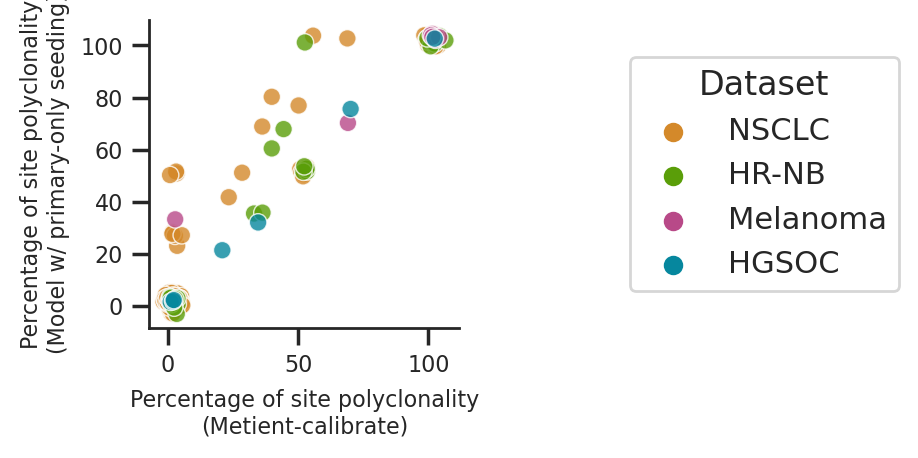

<Figure size 400x400 with 0 Axes>

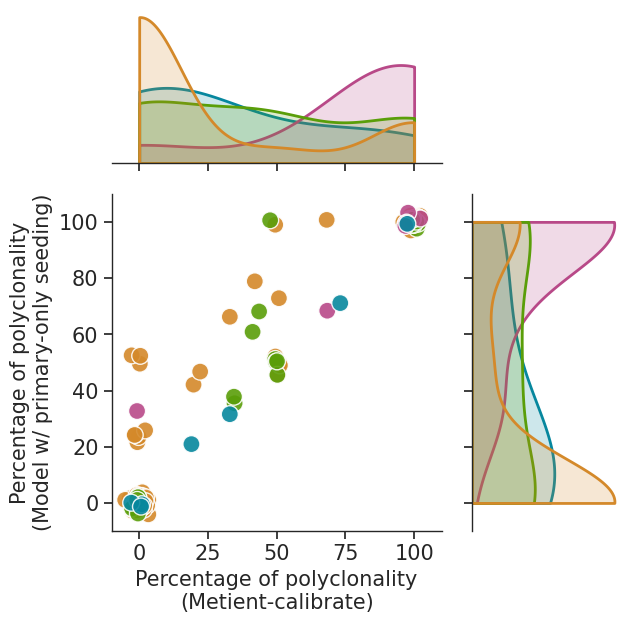

In [30]:

dataset_order = ['NSCLC','HR-NB','Melanoma','HGSOC']
colors = [four_dataset_colors[d] for d in dataset_order]
print(colors)
def joint_plot(df, keys, output_name, split_by_dataset):
    df = df.copy(deep=True)   
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2,2), dpi=200)
    df['Dataset'] = pd.Categorical(df['Dataset'], categories=dataset_order, ordered=True)
    # Sort the DataFrame based on the custom order of the 'Department' column
    df = df.sort_values(by='Dataset')
    
    hue = 'Dataset' if split_by_dataset else None
    g = sns.JointGrid(data=df, x=jitter(df[keys[0]], 0), y=jitter(df[keys[1]], 0), 
                      hue=hue, palette=colors, ratio=2, xlim=(-10,110), ylim=(-10,110))
    g.plot_joint(sns.scatterplot, s=150, alpha=0.9, hue=hue,palette=colors)
    g.plot_marginals(sns.kdeplot, common_norm=False, hue=hue,palette=colors, 
                     shade=True,clip=(0,100), linewidth=2, alpha=0.2,)
    g.set_axis_labels("Percentage of polyclonality\n(Metient-calibrate)", "Percentage of polyclonality\n(Model w/ primary-only seeding)",fontsize=15)
    g.ax_joint.tick_params(axis='both', labelsize=15)
    g.ax_marg_x.spines['left'].set_linewidth(2)

    g.ax_joint.legend_.remove()

    plt.savefig(os.path.join(OUTPUT_DIR,f"joint_plot_ssmodel_vs_calmodel_percent_polyclonal.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()

def jitter(values,j):
    return values + np.random.normal(j,1.5,values.shape)

def scatter_plot_comparison(df, keys, output_name): 
    df = df.copy(deep=True)   
    sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2,2), dpi=200)
    df['Dataset'] = pd.Categorical(df['Dataset'], categories=dataset_order, ordered=True)
    # Sort the DataFrame based on the custom order of the 'Department' column
    df = df.sort_values(by='Dataset')
    snsfig = sns.scatterplot(x=jitter(df[keys[0]], 2), y=jitter(df[keys[1]], 2), 
                             hue='Dataset', data=df, s=40,palette=colors)
    
    snsfig.legend(loc='center left', bbox_to_anchor=(1.5, 0.5), title='Dataset')
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.8)
    plt.xlabel("Percentage of site polyclonality\n(Metient-calibrate)", fontsize=8)
    plt.ylabel("Percentage of site polyclonality\n(Model w/ primary-only seeding)", fontsize=8)
    plt.savefig(os.path.join(OUTPUT_DIR,f"scatter_plot_ssmodel_vs_calmodel_percent_polyclonal.png"), dpi=500,  bbox_inches='tight', pad_inches=0.2)
    plt.show()
    plt.close()

scatter_plot_comparison(no_bc_df, ['Top cal % migs poly', 'Lowest ss % migs poly'], 'blah')
#scatter_hist_model_comparison(no_bc_df, ['Top cal % migs poly', 'Lowest ss % migs poly'], 'blah')
joint_plot(no_bc_df, ['Top cal % migs poly', 'Lowest ss % migs poly'], 'blah', True)


### Are there any significant differences between LUSC and LUAD subtypes?

['LUAD' 'LUSC']
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

LUAD v.s. LUSC: Welch's t-test independent samples, P_val=9.855e-01 stat=-1.821e-02


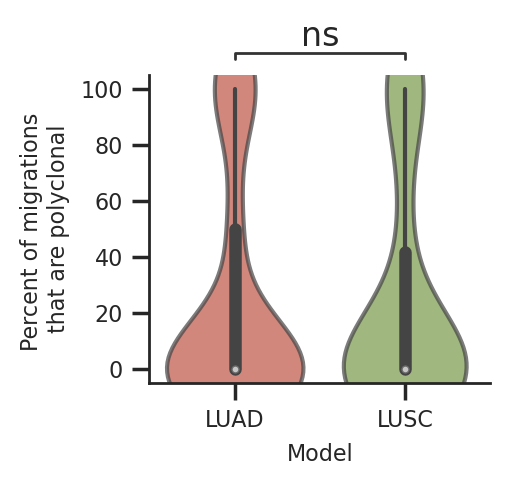

['LUAD' 'LUSC']
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

LUAD v.s. LUSC: Welch's t-test independent samples, P_val=9.767e-01 stat=-2.928e-02


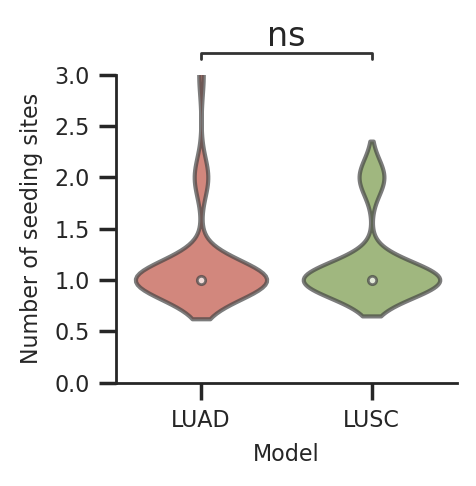

In [31]:

def box_plot_comparison_nsclc_subtypes(df, y,ylim,ylabel,output_name):
    
    sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 6, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.linewidth': 1.0})
    fig = plt.figure(figsize=(2.2,2), dpi=200)
    
    colors = ["#d44432", "#7aa63c"]
 
    snsfig = sns.violinplot(data=df, x='Subtype', y=y, 
                           dodge=True, palette=colors)
#     snsfig.set_xticklabels(['Seeding site \npenalizing model', 'Metient-calibrate'], rotation=0, fontsize=7)

    plt.xlabel("Model", fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.ylim(ylim[0],ylim[1])
    subtypes = nsclc_subset['Subtype'].unique()
    print(subtypes)
    add_stat_annotation(snsfig, data=df, x='Subtype', y=y,
                        box_pairs=[subtypes], line_offset=0.05,
                        test='t-test_welch', text_format='star', loc='outside', line_offset_to_box=0.00005, 
                        text_offset=0.00001, verbose=2,  fontsize=12, comparisons_correction=None,linewidth=1.0,
                        )    
    snsfig.spines['top'].set_visible(False)
    snsfig.spines['right'].set_visible(False)
    plt.setp(snsfig.collections, alpha=0.7)
    plt.savefig(os.path.join(OUTPUT_DIR,f"{output_name}_boxplot_ssmodel_vs_calmodel.png"), dpi=500,  bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close()


nsclc_subset = trees_df[(trees_df['Dataset']=='NSCLC') & (trees_df['Subtype']!='N/A')]
box_plot_comparison_nsclc_subtypes(nsclc_subset, "Top cal % migs poly", (-5,105), "Percent of migrations \nthat are polyclonal", 'num_migs_poly_calibrate_vs_lowest_ss')

box_plot_comparison_nsclc_subtypes(nsclc_subset, "Top cal num ss", (0,3), "Number of seeding sites", 'num_migs_poly_calibrate_vs_lowest_ss')



### What would the seeding pattern distributions be if we adopted the tie breaking model? (minimize migration # first, then comigration then seeding site)

In [35]:
import glob

data = []
for calibrate_dir,dataset in zip(CALIBRATE_DIRS, DATASET_NAMES):

    matching_files = glob.glob(f'{calibrate_dir}/*pkl.gz')
    patients = [m.split("/")[-1].split("_")[0] for m in matching_files]
    print("\n", dataset, len(patients))
    patterns = []
    for patient, fn in zip(patients, matching_files):
        pars_metrics = []
        with gzip.open(fn, 'rb') as f:
            pkl = pickle.load(f)
            loss_dicts = pkl[OUT_LOSS_DICT_KEY]
            for l in loss_dicts:
                pars_metrics.append((int(l[MIG_KEY]), int(l[COMIG_KEY]), int(l[SEEDING_KEY])))
            sorted_indices = sorted(enumerate(pars_metrics), key=lambda x: (x[1][0], x[1][1], x[1][2]))
            best_index = sorted_indices[0][0]
            if best_index != 0: 
                print("Different result:", dataset, patient)
            V = torch.tensor(pkl[OUT_LABElING_KEY][best_index])
            
            indices, values, size = pkl[OUT_ADJ_KEY][best_index]
            A = torch.sparse_coo_tensor(indices.cpu(), values.cpu(), tuple(size)).to_dense()
                
            pattern = putil.seeding_pattern(V,A)
            patterns.append(pattern)
            data.append([dataset, desired_order.index(pattern)])
    print(set(patterns))
    
    counts = Counter({p: 0 for p in desired_order})
    # Update counts with actual counts from data
    counts.update(patterns)
    print(counts)

tie_scheme_df = pd.DataFrame(data, columns=['Dataset', 'Seeding pattern'])



 HGSOC 13
Different result: HGSOC 3
{'primary single-source', 'single-source', 'multi-source'}
Counter({'primary single-source': 10, 'single-source': 2, 'multi-source': 1, 'reseeding': 0})

 Melanoma 7
{'primary single-source', 'single-source'}
Counter({'primary single-source': 6, 'single-source': 1, 'multi-source': 0, 'reseeding': 0})

 HR-NB 30
Different result: HR-NB H132387
Different result: HR-NB H132374
{'primary single-source', 'single-source', 'multi-source', 'reseeding'}
Counter({'primary single-source': 22, 'single-source': 5, 'multi-source': 2, 'reseeding': 1})

 NSCLC 128
Different result: NSCLC CRUK0748
Different result: NSCLC CRUK0465
Different result: NSCLC CRUK0245
{'primary single-source', 'single-source', 'multi-source', 'reseeding'}
Counter({'primary single-source': 107, 'single-source': 16, 'multi-source': 4, 'reseeding': 1})


### Of the NSCLC patients that have metastatic sites that seed, how many are LN

In [44]:
nsclc_df = trees_df[trees_df['Dataset']=='NSCLC']
sample_info_df = pd.read_csv(os.path.join(REPO_DIR, "tracerx_nsclc/","sample_overview_original.txt"), sep="\t")

pts_with_ln_seeding_site = []
pts_with_met_to_met_seeding = []
pts_with_ln_and_met_sites = []
for fn in nsclc_df['Filename']:
    with gzip.open(fn, 'rb') as f:
        pkl = pickle.load(f)
        
        # Best calibrated tree
        V = torch.tensor(pkl[OUT_LABElING_KEY][0])
        indices, values, size = pkl[OUT_ADJ_KEY][0]
        A = torch.sparse_coo_tensor(indices.cpu(), values.cpu(), tuple(size)).to_dense()
        
        sites = pkl[OUT_SITES_KEY]
        primary_site = pkl[OUT_PRIMARY_KEY]
        G = putil.migration_graph(V,A)
        pid = os.path.basename(fn).replace(".pkl.gz", "")
        ln_sites, distant_sites = [], []
        seeding_sites = set()
        
        has_ln, has_distant = False, False
        for site in sites:
            if site != primary_site:
                if ut.is_ln(site):
                    has_ln = True
                else:
                    has_distant = True
        if has_distant and has_ln:
            pts_with_ln_and_met_sites.append(pid)
            
        for i,seeding_site in enumerate(sites):
            for j, seeded_site in enumerate(sites):
                if i == j or G[i,j] == 0: 
                    continue
                
                seeding_sites.add(seeding_site)
        pid = os.path.basename(fn).replace(".pkl.gz", "")
            
        seeding_sites = list(seeding_sites)
        primary_only_seeding = True if len(set(seeding_sites)) == 1 else False
        if not primary_only_seeding:
            pts_with_met_to_met_seeding.append(pid)
            has_ln_seeding_site = False
            for site in seeding_sites:
                if ut.is_ln(site):
                    has_ln_seeding_site = True
                    
            if has_ln_seeding_site:
                pts_with_ln_seeding_site.append(pid)
                print(pid, "has_ln_seeding_site", seeding_sites)
            
print(len(pts_with_ln_and_met_sites), pts_with_ln_and_met_sites)
print("pts_with_ln_seeding_site", len(pts_with_ln_seeding_site))
print("pts_with_met_to_met_seeding", len(pts_with_met_to_met_seeding), pts_with_met_to_met_seeding)

CRUK0010_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0013_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_LN2']
CRUK0029_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0256_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0290_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_LN1']
CRUK0311_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0468_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0487_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN2', 'LN_SU_FLN3']
CRUK0559_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1', 'LN_SU_LN2']
CRUK0698_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
CRUK0736_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_LN1']
CRUK0810_primary_SU_T1 has_ln_seeding_site ['primary_SU_T1', 'LN_SU_FLN1']
20 ['CRUK0010_primary_SU_T1', 'CRUK0029_primary_SU_T1', 'CRUK0035_primary_SU

In [45]:
pts_with_ln_seeding_site

['CRUK0010_primary_SU_T1',
 'CRUK0013_primary_SU_T1',
 'CRUK0029_primary_SU_T1',
 'CRUK0256_primary_SU_T1',
 'CRUK0290_primary_SU_T1',
 'CRUK0311_primary_SU_T1',
 'CRUK0468_primary_SU_T1',
 'CRUK0487_primary_SU_T1',
 'CRUK0559_primary_SU_T1',
 'CRUK0698_primary_SU_T1',
 'CRUK0736_primary_SU_T1',
 'CRUK0810_primary_SU_T1']

1_calibrate_Left Ovary [] ['Right Ovary', 'Appendix', 'Left Fallopian Tube', 'Omentum', 'Right Fallopian Tube', 'Small Bowel'] 2 6
10_calibrate_Right Ovary [] ['Left Fallopian Tube', 'Omentum'] 4 8
2_calibrate_Right Ovary [] ['Omentum'] 4 9
3_calibrate_Left Ovary [] ['Right Ovary', 'Adnexa', 'Cul de Sac', 'Left Fallopian Tube Fimbriae', 'Omentum', 'Right Fallopian Tube', 'Sigmoid Colon Deposit'] 9 16
4_calibrate_Right Ovary [] ['Left Ovary Surface', 'Left Pelvic Sidewall', 'Right Pelvic Sidewall'] 9 19
7_calibrate_Right Uterosacral [] ['Left Ovary', 'Right Ovary', 'Bowel Implant', 'Brain Metastasis', 'Righ Pelvic Mass'] 10 24
9_calibrate_Left Ovary [] ['Right Ovary', 'Omentum'] 10 26
H103207_calibrate_primary, left adrenal [] ['left lung lower lobe', 'liver', 'right lung lower lobe', 'brain, cerebellum', 'brain, right frontal'] 12 31
H112908_calibrate_primary, left mediastinal [] ['brain'] 12 32
H112909_calibrate_primary, left mediastinal [] ['brain'] 12 33
H112910_calibrate_primary, a

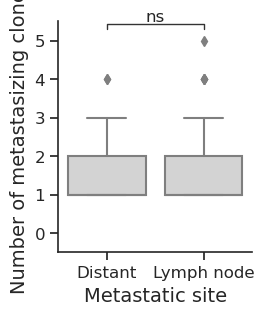

34     1
39     3
44     3
55     1
60     1
      ..
307    1
308    1
309    1
310    1
313    1
Name: Number of metastasizing clones, Length: 157, dtype: int64


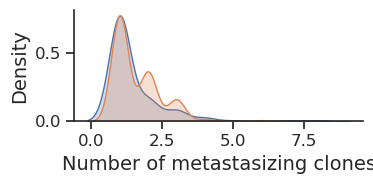

In [48]:

met_site_polyclonal_data, met_site_phyletic_data = [], []


num_polyclonal_sites, num_all_seeded_sites = 0,0
for fn,dataset in zip(trees_df['Filename'], trees_df['Dataset']):
    pts_with_ln_seeding_sites, pts_with_distant_seeding_sites = 0,0
    with gzip.open(fn, 'rb') as f:
        pkl = pickle.load(f)
        
        # Best calibrated tree
        V = torch.tensor(pkl[OUT_LABElING_KEY][0])
        indices, values, size = pkl[OUT_ADJ_KEY][0]
        A = torch.sparse_coo_tensor(indices.cpu(), values.cpu(), tuple(size))
        sites = pkl[OUT_SITES_KEY]
        primary_site = pkl[OUT_PRIMARY_KEY]
        idx_to_label = pkl[OUT_IDX_LABEL_KEY][0]
        G = putil.migration_graph(V,A)
        pid = os.path.basename(fn).replace(".pkl.gz", "")
        ln_sites, distant_sites = [], []
        
        for i,seeding_site in enumerate(sites):
            for j, seeded_site in enumerate(sites):
                if i == j or G[i,j] == 0: 
                    continue
                is_polyclonal = int(G[i,j]>1)
                if is_polyclonal:
                    num_polyclonal_sites += 1
                num_all_seeded_sites += 1
                category = "Lymph node" if ut.is_ln(seeded_site) else "Distant"
                if category == "Lymph node":
                    ln_sites.append(seeded_site)
                else:
                    distant_sites.append(seeded_site)
                met_site_polyclonal_data.append([dataset, pid, category, is_polyclonal, int(G[i,j])])
        
        print(pid, ln_sites, distant_sites, num_polyclonal_sites, num_all_seeded_sites)
        if len(ln_sites) > 0:
            site_indices = [sites.index(site) for site in ln_sites]
            ln_phyletic = putil.phyleticity(V, A, idx_to_label, sites=site_indices)
            met_site_phyletic_data.append([dataset, pid, "Lymph node", ln_phyletic])
        if len(distant_sites) > 0:
            site_indices = [sites.index(site) for site in distant_sites]
            distant_phyletic = putil.phyleticity(V, A, idx_to_label, sites=site_indices)
            met_site_phyletic_data.append([dataset, pid, "Distant", distant_phyletic])
            
met_site_to_polyclonal_df = pd.DataFrame(data=met_site_polyclonal_data, columns=["Dataset", "Patient", "Metastatic site", "Is polyclonal", "Number of metastasizing clones"])

fig = plt.figure(figsize=(2.5,3))
sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'axes.linewidth': 1.2})

colors = ["lightgrey", "lightgrey"]

snsfig = sns.boxplot(data=met_site_to_polyclonal_df, x='Metastatic site', y="Number of metastasizing clones", 
                       dodge=True, palette=colors)
plt.xlabel("Metastatic site")
plt.ylabel("Number of metastasizing clones")
plt.ylim(-0.5,5.5)
subtypes = met_site_to_polyclonal_df["Metastatic site"].unique()
add_stat_annotation(snsfig, data=met_site_to_polyclonal_df, x='Metastatic site', y="Number of metastasizing clones",
                    box_pairs=[subtypes], line_offset=0.05,
                    test='t-test_welch', text_format='star', loc='outside', line_offset_to_box=0.00005, 
                    text_offset=0.00001, verbose=2,  fontsize=12, comparisons_correction=None,linewidth=1.0,
                    )    
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR,f"num_met_clones_ln_vs_other_boxplot.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close()


fig, ax = plt.subplots(1, 1, figsize=(4, 2))
sns.set(style='ticks', font="Arial", rc={'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'axes.linewidth': 1.2})
ln_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Lymph node']
distant_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Distant']
print(ln_df["Number of metastasizing clones"])
sns.kdeplot(ln_df["Number of metastasizing clones"], ax=ax, fill=True)
snsfig= sns.kdeplot(distant_df["Number of metastasizing clones"], ax=ax, fill=True)

snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [49]:
num_polyclonal_sites, num_all_seeded_sites

(107, 314)

### How often are migrating clones to LNs vs Distant mets

In [50]:
met_site_phyletic_df = pd.DataFrame(data=met_site_phyletic_data, columns=["Dataset", "Patient", "Metastatic site", "Phyleticity"])
met_site_phyletic_df
distant_phyl_df = met_site_phyletic_df[met_site_phyletic_df['Metastatic site']=='Distant']
print("Distant mets phyleticity:\n", distant_phyl_df['Phyleticity'].value_counts())
ln_phyl_df = met_site_phyletic_df[met_site_phyletic_df['Metastatic site']=='Lymph node']
print("LN mets phyleticity:\n", ln_phyl_df['Phyleticity'].value_counts())



Distant mets phyleticity:
 monophyletic    76
polyphyletic    17
Name: Phyleticity, dtype: int64
LN mets phyleticity:
 monophyletic    83
polyphyletic    20
Name: Phyleticity, dtype: int64


In [51]:
met_site_phyletic_df[met_site_phyletic_df['Patient']=='CRUK0484_primary_SU_T1']

,Dataset,Patient,Metastatic site,Phyleticity
127,NSCLC,CRUK0484_primary_SU_T1,Lymph node,polyphyletic
128,NSCLC,CRUK0484_primary_SU_T1,Distant,polyphyletic


### What are the percentages of polcylonal metastases to the lymph, to distant?

In [52]:
distant_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Distant']
print("Distant mets polyclonality:\n", distant_df['Is polyclonal'].value_counts())
ln_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Lymph node']
print("LN mets polyclonality:\n", ln_df['Is polyclonal'].value_counts())


Distant mets polyclonality:
 0    92
1    65
Name: Is polyclonal, dtype: int64
LN mets polyclonality:
 0    115
1     42
Name: Is polyclonal, dtype: int64


In [53]:
met_site_to_polyclonal_df

,Dataset,Patient,Metastatic site,Is polyclonal,Number of metastasizing clones
0,HGSOC,1_calibrate_Left Ovary,Distant,1,3
1,HGSOC,1_calibrate_Left Ovary,Distant,0,1
2,HGSOC,1_calibrate_Left Ovary,Distant,1,2
3,HGSOC,1_calibrate_Left Ovary,Distant,0,1
4,HGSOC,1_calibrate_Left Ovary,Distant,0,1
...,...,...,...,...,...
309,NSCLC,CRUK0810_primary_SU_T1,Lymph node,0,1
310,NSCLC,CRUK0810_primary_SU_T1,Lymph node,0,1
311,NSCLC,CRUK0810_primary_SU_T1,Distant,0,1
312,NSCLC,CRUK0817_primary_SU_T1,Distant,0,1


### Distribution of each dataset's polyclonal migrations, lymph node vs. distant met

HGSOC nan 1.5384615384615385
HR-NB 1.6 1.6888888888888889
Melanoma 2.0 2.1875
NSCLC 1.4615384615384615 1.4


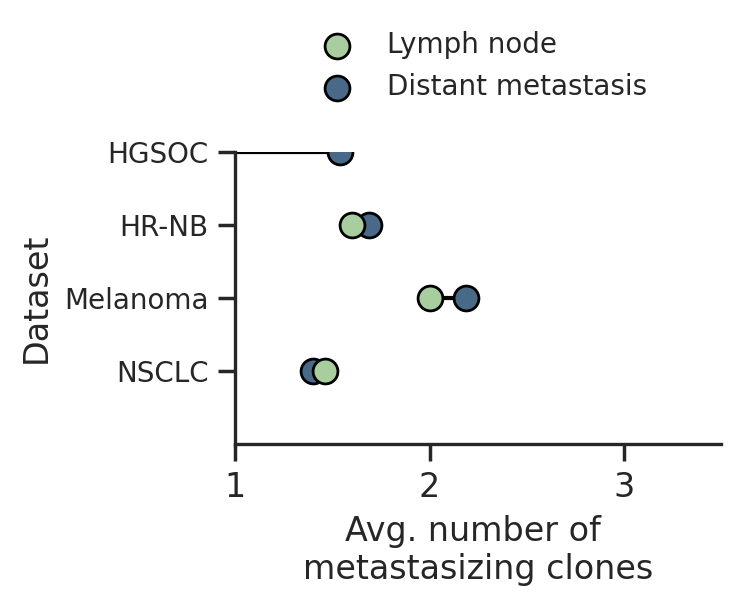

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=200)

data = []

j = len(met_site_to_polyclonal_df['Dataset'].unique()) - 1
for i, dataset in enumerate(met_site_to_polyclonal_df['Dataset'].unique()):
    sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 10, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'axes.linewidth': 1.2})
    dataset_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Dataset']==dataset]
    ln_clones = dataset_df[(dataset_df['Metastatic site']=='Lymph node')]["Number of metastasizing clones"]
    distant_clones = dataset_df[(dataset_df['Metastatic site']=='Distant')]["Number of metastasizing clones"]
    ln_clones_mean = ln_clones.mean() if len(ln_clones) > 0 else 0.0
    distant_clones_mean = distant_clones.mean() if len(distant_clones) > 0 else 0.0
    print(dataset, ln_clones.mean(), distant_clones.mean())
    p1 = plt.scatter(ln_clones_mean, j, c='#A8CD9F', s=80, zorder=3, ec='black', label='Lymph node')
    plt.scatter(distant_clones_mean, j, c='#496989', s=80, zorder=2, ec='black', label='Distant')
    plt.plot((ln_clones_mean, distant_clones_mean), (j, j), c='black', zorder=1, alpha=1, linewidth=1.5)
    plt.xlim((1,3.5))
    plt.ylim((-1,2.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    j -= 1

plt.yticks([3,2, 1, 0], met_site_to_polyclonal_df['Dataset'].unique(), fontsize=10)
plt.xlabel("Avg. number of \nmetastasizing clones", fontsize=12)
plt.ylabel("Dataset", fontsize=12)

legend_labels = ['Lymph node', 'Distant metastasis']
plt.legend(legend_labels, loc='upper center',  bbox_to_anchor=(0.5, 1.5), ncol=1, 
           frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f"avg_num_met_clones.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)

plt.show()

['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Lymph node']
['Distant']
['Distant']
['Distant']
['Distant' 'Lymph node']
['Distant' 'Lymph node']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Distant' 'Lymph node']
['Distant']
['Distant' 'Lymph node']
['Lymph node']
['Distant']
['Distant']
['Distant']
['Distant']
['Lymph node' 'Distant']
['Distant']
['Distant']
['Lymph node' 'Distant']
['Distant']
['Distant' 'Lymph node']
['Distant' 'Lymph node']
['Lymph node' 'Distant']
['Distant']
['Lymph node']
['Distant']
['Lymph node']
['Lymph node' 'Distant']
['Lymph node']
['Lymph node']
['Lymph node']
['Lymph node' 'Distant']
['Lymph node' 'Distant']
['Distant']
['Distant']
['Distant']
['Distant']
['Lymph node']
['Lymph node' 'Distant']
['Distant']
['Lymph node']
['Distant']
['Lymph node']
['Lymph node']
['Distant']
['Lymph node']
['Distant']
['Lymph node']
['Lymph node

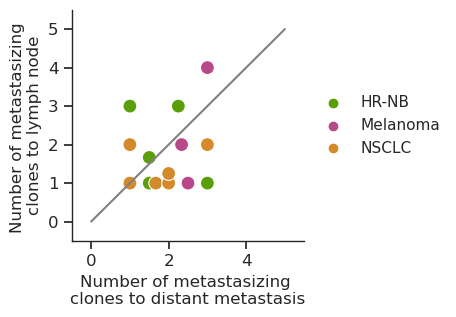

In [55]:
import math
patients = met_site_to_polyclonal_df['Patient'].unique()
ln_avg_num_clones = []
other_met_avg_num_clones = []
ct = 0
paired_data_num_met_clones = []
datasets = []
for patient in patients:
    pt_subset = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Patient']==patient]
    print(pt_subset['Metastatic site'].unique())
    ln_avg = pt_subset[pt_subset['Metastatic site']=='Lymph node']['Number of metastasizing clones'].mean()
    other_avg = pt_subset[pt_subset['Metastatic site']=='Distant']['Number of metastasizing clones'].mean()
    if not math.isnan(ln_avg) and  not math.isnan(other_avg):
        #print(pt_subset, ln_avg, other_avg)
        ln_avg_num_clones.append(ln_avg)
        other_met_avg_num_clones.append(other_avg)
        dataset = pt_subset['Dataset'].unique().item()
        paired_data_num_met_clones.append([patient, dataset, ln_avg, other_avg])
        ct += 1

sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 18, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'axes.linewidth': 1.0})
plt.figure(figsize=(3, 3))
paired_df = pd.DataFrame(paired_data_num_met_clones, columns=["Patient", "Dataset", "LN average", "Other met average"])
datasets = paired_df['Dataset'].unique()
snsfig = sns.scatterplot(data=paired_df, x="Other met average",y="LN average", hue="Dataset",
                         s=100, palette=[four_dataset_colors[d] for d in datasets], alpha=1.0, edgecolors='face', linewidths=4)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.plot([0, 5], [0, 5],color='grey')
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.xlabel("Number of metastasizing \nclones to distant metastasis", fontsize=12)
plt.ylabel("Number of metastasizing \nclones to lymph node", fontsize=12)
plt.xlim(-0.5,5.5)
plt.ylim(-0.5,5.5)
plt.savefig(os.path.join(OUTPUT_DIR,f"num_met_clones_ln_vs_other_scatterplot.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close()

In [56]:
import scipy.stats as stats 
  
# paired sample t-test 
s = stats.ttest_rel(paired_df['LN average'], paired_df['Other met average']) 
s.pvalue

0.5162540350922825

0.267515923566879 0.4140127388535032
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Distant v.s. Lymph node: Welch's t-test independent samples, P_val=6.072e-03 stat=2.763e+00
0.0 27.3515923566879
1.0 42.00127388535032


/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


157 42/157
157 65/157


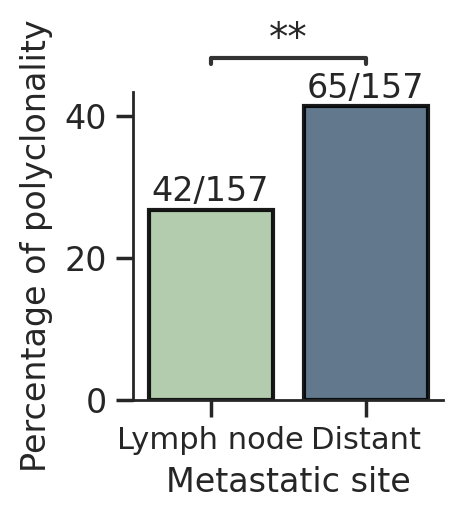

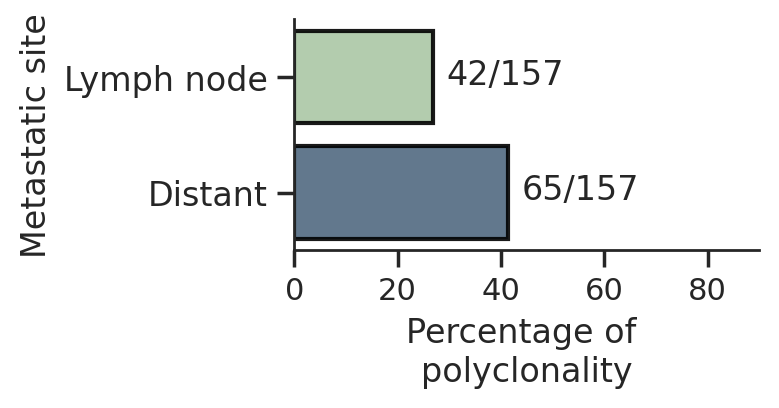

In [57]:
ln_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Lymph node']
other_df = met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=='Distant']
ln_percent = len(ln_df[ln_df['Is polyclonal']==1])/(len(ln_df[ln_df['Is polyclonal']==0])+ len(ln_df[ln_df['Is polyclonal']==1]))
other_percent = len(other_df[other_df['Is polyclonal']==1])/(len(other_df[other_df['Is polyclonal']==0])+ len(other_df[other_df['Is polyclonal']==1]))
print(ln_percent, other_percent, )

plt.figure(figsize=(2,2), dpi=200)
sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 12, 'axes.linewidth': 1.0})

snsfig = sns.barplot(['Lymph node', 'Distant'], [ln_percent*100, other_percent*100],dodge=True,
                     palette=['#A8CD9F','#496989'], alpha=0.9,edgecolor='black', linewidth=1.5,)

add_stat_annotation(snsfig, data=met_site_to_polyclonal_df,
                    x='Metastatic site', y='Is polyclonal',
                    box_pairs=[["Lymph node", "Distant"]],test='t-test_welch', text_format='star', line_offset=0.1,
                    loc='outside', line_offset_to_box=0.01, text_offset=0.01, verbose=2,  fontsize=14, 
                    comparisons_correction=None,linewidth=1.5,
                    )
for p,df in zip(snsfig.patches, [ln_df, other_df]):
    
    denom = len(df[df['Is polyclonal']==1])+len(df[df['Is polyclonal']==0])
    frac = f"{len(df[df['Is polyclonal']==1])}/{denom}"
    print(p.get_x() + p.get_width() / 2., p.get_height()+0.6)
    snsfig.annotate(frac, 
                (p.get_x() + p.get_width() / 2., p.get_height()+0.6), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points',font="Arial")
plt.xlabel("Metastatic site")
plt.ylabel("Percentage of polyclonality")
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR,f"percent_polyclonality_ln_vs_other.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)

# horizontal version
plt.figure(figsize=(3,1.5), dpi=200)
sns.set(style='ticks', font="Helvetica", rc={'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 12, 'axes.linewidth': 1.0})

snsfig = sns.barplot([ln_percent*100, other_percent*100],['Lymph node', 'Distant'], dodge=True,
                     palette=['#A8CD9F','#496989'], alpha=0.9,edgecolor='black', linewidth=1.5,)
for p,df in zip(snsfig.patches, [ln_df, other_df]):
    
    denom = len(df[df['Is polyclonal']==1])+len(df[df['Is polyclonal']==0])
    frac = f"{len(df[df['Is polyclonal']==1])}/{denom}"
    print( denom, frac)
    snsfig.annotate(frac, 
                (p.get_width()+14, p.get_y() + p.get_height()/2+0.1), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points',font="Arial")
plt.xlim(0,90)
plt.ylabel("Metastatic site")
plt.xlabel("Percentage of \npolyclonality")
snsfig.spines['top'].set_visible(False)
snsfig.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR,f"percent_polyclonality_ln_vs_other_horiz.png"), dpi=500,  bbox_inches='tight', pad_inches=0.05)




In [58]:
print(ln_df['Is polyclonal'].value_counts(), )
print(other_df['Is polyclonal'].value_counts())

0    115
1     42
Name: Is polyclonal, dtype: int64
0    92
1    65
Name: Is polyclonal, dtype: int64


In [59]:
met_site_to_polyclonal_df[met_site_to_polyclonal_df['Metastatic site']=="Distant"]["Number of metastasizing clones"].mean()


1.585987261146497

### How often is metastatic potential poly vs monophyletic in each dataset

{'Monophyletic': '#bf7ea2', 'Polyphyletic': '#407891'}


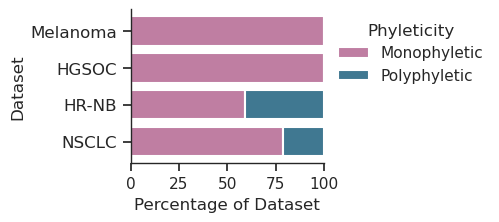

{'Monoclonal': '#bf7ea2', 'Polyclonal': '#407891'}


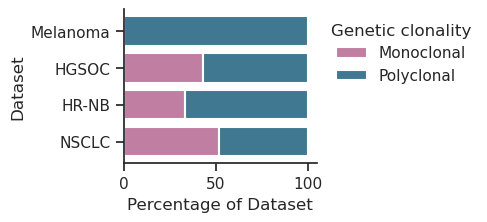

{'Monoclonal': '#bf7ea2', 'Polyclonal': '#407891'}


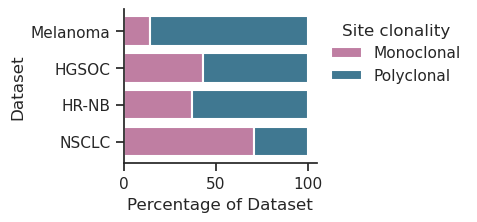

In [60]:
def horizontal_bar(proportions, desired_order, legend_title, output_name):
    fig, ax = plt.subplots(figsize=(2.5,2))

    # Variables to store the bottom for each bar
    bottoms = np.zeros(len(proportions))

    # Colors for each category
    #"#41b7c2", "#00879e",
    tab_colors = ["#bf7ea2","#407891"]
    colors = {d:c for d,c in zip(desired_order, tab_colors)}
    print(colors)
    sns.set(style='ticks', font="Arial")
    # Plot each category
    for column_name in desired_order:
        column_data = proportions[column_name]
        ax.barh(proportions.index, column_data,left=bottoms, label=column_name, 
               color=colors[column_name], edgecolor='white', linewidth=1.5)
        bottoms += column_data.values

    ax.set_xlabel('Percentage of Dataset')
    ax.set_ylabel('Dataset')
    legend = ax.legend(title=legend_title, bbox_to_anchor=(1, 1), loc='upper left', frameon=False)  # Place legend outside the plot
    for text in legend.get_texts():
        text.set_text(text.get_text().capitalize())
        
     # Remove top and right axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{output_name}_dataset_distribution.png"), dpi=300,  bbox_inches='tight', pad_inches=0.05)

    plt.show()
    plt.close()
    
df = trees_df[trees_df['Dataset']!='Breast Cancer']
df['Top cal phyleticity'] = df.apply(lambda row: row["Top cal phyleticity"].capitalize(), axis=1)
df['Top cal genetic clonality'] = df.apply(lambda row: row["Top cal genetic clonality"].capitalize(), axis=1)
df['Top cal site clonality'] = df.apply(lambda row: row["Top cal site clonality"].capitalize(), axis=1)

phyletic_counts = df.groupby(['Dataset', 'Top cal phyleticity']).size().unstack(fill_value=0)
phyletic_proportions = phyletic_counts.div(phyletic_counts.sum(axis=1), axis=0)*100
phyletic_proportions = phyletic_proportions.reindex(['NSCLC', "HR-NB","HGSOC", "Melanoma", ])
horizontal_bar(phyletic_proportions, ["Monophyletic", "Polyphyletic"], "Phyleticity", "phyletic")

genetic_clonality_counts = df.groupby(['Dataset', 'Top cal genetic clonality']).size().unstack(fill_value=0)
genetic_clonality_proportions = genetic_clonality_counts.div(genetic_clonality_counts.sum(axis=1), axis=0)*100
genetic_clonality_proportions = genetic_clonality_proportions.reindex(['NSCLC', "HR-NB","HGSOC", "Melanoma", ])
horizontal_bar(genetic_clonality_proportions, ["Monoclonal", "Polyclonal"], "Genetic clonality", "genetic_clonality")

site_clonality_counts = df.groupby(['Dataset', 'Top cal site clonality']).size().unstack(fill_value=0)
site_clonality_proportions = site_clonality_counts.div(site_clonality_counts.sum(axis=1), axis=0)*100
site_clonality_proportions = site_clonality_proportions.reindex(['NSCLC', "HR-NB","HGSOC", "Melanoma", ])
horizontal_bar(site_clonality_proportions, ["Monoclonal", "Polyclonal"], "Site clonality", "site_clonality")


In [62]:
phyletic_counts

Top cal phyleticity,Monophyletic,Polyphyletic
Dataset,,
HGSOC,7,0
HR-NB,16,11
Melanoma,7,0
NSCLC,99,27


In [63]:
genetic_clonality_counts

Top cal genetic clonality,Monoclonal,Polyclonal
Dataset,,
HGSOC,3,4
HR-NB,9,18
Melanoma,0,7
NSCLC,65,61


In [64]:
site_clonality_counts

Top cal site clonality,Monoclonal,Polyclonal
Dataset,,
HGSOC,3,4
HR-NB,10,17
Melanoma,1,6
NSCLC,89,37
